In [1]:
from google.colab import files
uploaded = files.upload()

Saving jalanan.jpg to jalanan.jpg


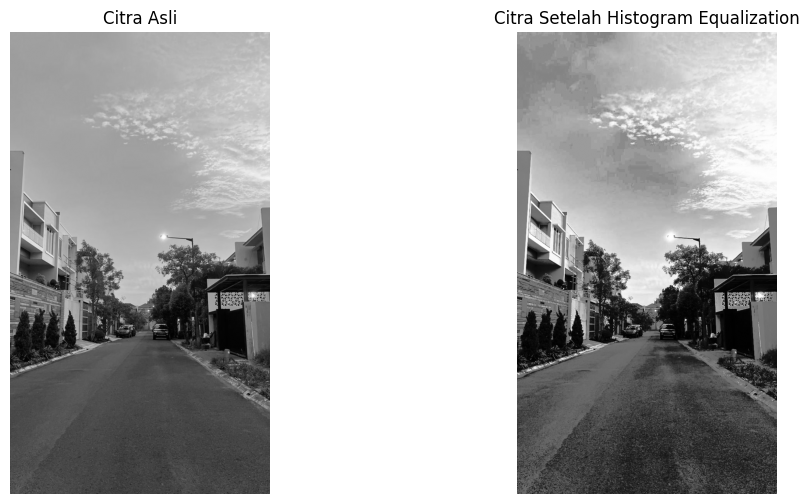

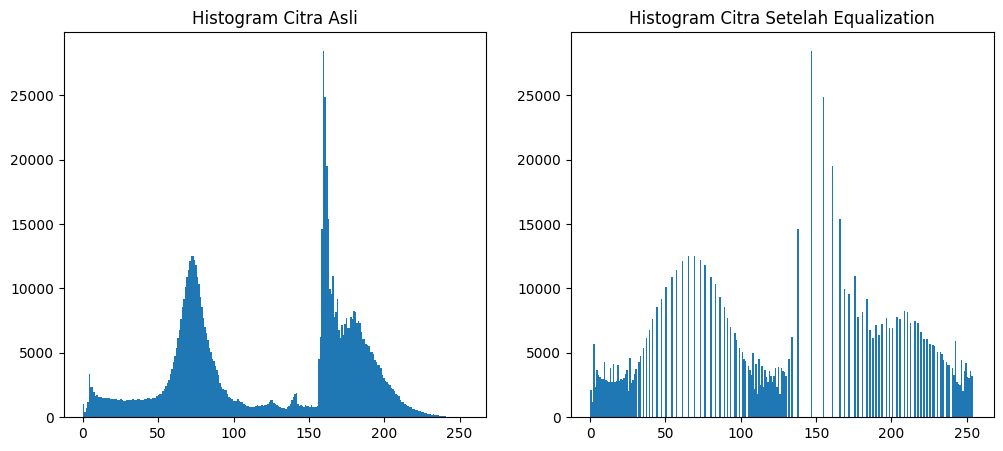

In [ ]:
# ==========================================
# PRAKTIKUM: HISTOGRAM EQUALIZATION MANUAL
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====================================
# Fungsi Histogram Equalization Manual
# ====================================

def manual_histogram_equalization(image):
    """
    Manual implementation of histogram equalization

    Parameters:
    image : Input grayscale image (0-255)

    Returns:
    equalized_image : Image after histogram equalization
    transform : Transformation function
    """

    # 1. Hitung histogram
    histogram = np.zeros(256)

    for pixel in image.flatten():
        histogram[pixel] += 1

    # 2. Hitung cumulative histogram (CDF)
    cdf = histogram.cumsum()

    # Normalisasi CDF
    cdf_normalized = cdf / cdf[-1]

    # 3. Hitung transformation function
    transform = np.floor(255 * cdf_normalized).astype(np.uint8)

    # 4. Apply transformation
    equalized_image = transform[image]

    # 5. Return hasil
    return equalized_image, transform


# ==============
# Load Gambar
# ==============

# Upload gambar ke Colab terlebih dahulu
image = cv2.imread('jalanan.jpg', cv2.IMREAD_GRAYSCALE)

# ===============================
# Proses Histogram Equalization
# ===============================

equalized_image, transform = manual_histogram_equalization(image)

# ====================
# Menampilkan Hasil
# ====================

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Citra Asli")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Citra Setelah Histogram Equalization")
plt.imshow(equalized_image, cmap='gray')
plt.axis('off')

plt.show()

# ========================
# Menampilkan Histogram
# ========================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Histogram Citra Asli")
plt.hist(image.flatten(), bins=256)

plt.subplot(1,2,2)
plt.title("Histogram Citra Setelah Equalization")
plt.hist(equalized_image.flatten(), bins=256)

plt.show()